# AZT1D Exploratory Data Analysis

**Dataset:** AZT1D — A Real-World Dataset for Type 1 Diabetes
**Source:** Khamesian, Arefeen, Thompson, Grando & Ghasemzadeh (2025). [arXiv:2506.14789](https://arxiv.org/abs/2506.14789)
**Data:** Mendeley Data, [doi:10.17632/gk9m674wcx.1](https://doi.org/10.17632/gk9m674wcx.1) (CC BY 4.0)

25 individuals with type 1 diabetes on automated insulin delivery (Tandem t:slim X2,
Control-IQ) were followed for 6-8 weeks each at Mayo Clinic Arizona (Dec 2023-Apr 2024).
Each subject's record stream carries: CGM (Dexcom G6 Pro, 5-min interval), basal insulin
(forward-filled from sparse logged readings), bolus insulin (with type: standard /
correction / automatic / extended, split into food vs. correction portions), carbohydrate
intake, and device mode (regular / sleep / exercise).

> **Status of this notebook:** now running against the **real dataset** (dropped into
> `data/raw/CGM Records/` as an already-extracted folder rather than the Mendeley zip --
> the loader in Section 1 handles either). A few real-data quirks surfaced once we could
> see actual files, and are now handled in `azt1d/loading.py`: one subject uses a
> differently-named CGM column, ~2% of rows were exact duplicates (one timestamp had ~1900
> identical copies), `Basal` is logged sparsely rather than pre-filled and needed forward-
> filling, some `Basal` readings were physiologically impossible export glitches (clipped),
> and `DeviceMode`/`BolusType` had stray `'0'` placeholder strings. If `data/raw/` is ever
> empty (e.g. a fresh checkout without the data), this notebook falls back to a synthetic
> placeholder dataset with the same schema instead of failing.


In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT / "src"))

from azt1d import reference as ref
from azt1d import loading, metrics, plotting, synthetic

plotting.apply_style()
pd.set_option("display.max_columns", None)


## 1. Load data (real if present, else synthetic placeholder)

`loading.load_real_dataset` looks for either a `.zip` or an already-extracted folder of
per-subject CSVs in `data/raw/`, discovers each subject's file (confirmed layout:
`CGM Records/Subject N/Subject N.csv`), normalizes column names against the schema in
`azt1d.reference`, cleans up the real-data quirks noted above, and concatenates everything
with a `subject_id` column. If nothing is found yet, we fall back to synthetic data.


In [2]:
RAW_DIR = PROJECT_ROOT / "data" / "raw"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
SYNTHETIC_DIR = PROCESSED_DIR / "synthetic"

# "Real data present" means either a downloaded zip, or an already-extracted
# folder of per-subject CSVs dropped straight into data/raw/ (both happened
# across this project's life -- loading.load_real_dataset handles either).
has_real_data = loading.find_dataset_zip(RAW_DIR) is not None or bool(loading.discover_subject_files(RAW_DIR))

if has_real_data:
    print("Found real AZT1D data in data/raw/ -- loading it.")
    df = loading.load_real_dataset(RAW_DIR, PROCESSED_DIR)
    USING_SYNTHETIC = False
else:
    print("No real dataset found in data/raw/ yet -- using synthetic placeholder data.")
    if not any(SYNTHETIC_DIR.glob("*.csv")):
        synthetic.write_synthetic_csvs(SYNTHETIC_DIR)
    df = loading.load_all_subjects(SYNTHETIC_DIR)
    USING_SYNTHETIC = True

print(f"Loaded {len(df):,} rows across {df['subject_id'].nunique()} subjects.")
df.head()


Found real AZT1D data in data/raw/ -- loading it.


Loaded 300,923 rows across 25 subjects.


,subject_id,EventDateTime,Basal,CorrectionDelivered,TotalBolusInsulinDelivered,FoodDelivered,CarbSize,CGM,DeviceMode,BolusType
0,1,2023-12-08 00:04:00,2.2,0.0,0.0,0.0,0.0,151.0,NaN,NaN
1,1,2023-12-08 00:09:00,2.2,0.0,0.0,0.0,0.0,152.0,NaN,NaN
2,1,2023-12-08 00:14:00,2.2,0.0,0.0,0.0,0.0,156.0,NaN,NaN
3,1,2023-12-08 00:19:00,2.2,0.0,0.0,0.0,0.0,158.0,NaN,NaN
4,1,2023-12-08 00:24:00,2.2,0.0,0.0,0.0,0.0,160.0,NaN,NaN


## 2. Structural checks

Quick sanity checks before trusting anything downstream: dtypes, value ranges, missingness,
and the categorical fields we expect (`DeviceMode`, `BolusType`).


In [3]:
print(df.dtypes)
print()
print("Missing values per column:")
print(df.isna().sum())


subject_id                             int64
EventDateTime                 datetime64[us]
Basal                                float64
CorrectionDelivered                  float64
TotalBolusInsulinDelivered           float64
FoodDelivered                        float64
CarbSize                             float64
CGM                                  float64
DeviceMode                            object
BolusType                                str
dtype: object

Missing values per column:
subject_id                         0
EventDateTime                      0
Basal                              0
CorrectionDelivered                0
TotalBolusInsulinDelivered         0
FoodDelivered                      0
CarbSize                           0
CGM                                0
DeviceMode                    242313
BolusType                     290378
dtype: int64


In [4]:
print("CGM range:", df[ref.CGM].min(), "-", df[ref.CGM].max(), "mg/dL")
print("Basal range:", df[ref.BASAL].min(), "-", df[ref.BASAL].max(), "U/hr")
print("Device modes (excl. blank = regular):", sorted(df[ref.DEVICE_MODE].dropna().unique()))
print(f"  blank/regular: {df[ref.DEVICE_MODE].isna().mean():.1%} of rows")
print("Bolus types (incl. blank = no bolus event):", sorted(df[ref.BOLUS_TYPE].fillna("").unique())[:10], "...")
print()
print("Readings per subject:")
print(df.groupby("subject_id").size().describe())


CGM range: 40.0 - 400.0 mg/dL
Basal range: 0.0 - 13.0 U/hr
Device modes (excl. blank = regular): ['exercise', 'sleep']
  blank/regular: 80.5% of rows
Bolus types (incl. blank = no bolus event): ['', 'Automatic Bolus/Correction', 'BLE Standard Bolus', 'BLE Standard Bolus/Correction', 'Extended 10.00%/0.00', 'Extended 20.00%/0.00', 'Extended 25.00%/1.85', 'Extended 25.00%/3.75', 'Extended 25.00%/4.16', 'Extended 25.00%/5.60'] ...

Readings per subject:
count       25.000000
mean     12036.920000
std       1387.902162
min       8040.000000
25%      10881.000000
50%      12634.000000
75%      13052.000000
max      13772.000000
dtype: float64


## 3. Demographics

Table I from the paper (age, sex, A1c) is transcribed in `azt1d.reference.DEMOGRAPHICS_TABLE1`
so it's available regardless of what ships inside the archive. **Caveat:** the paper's
patient index is used here as `subject_id` provisionally — confirm this join once the real
per-subject files are extracted and their actual IDs are visible.


,subject_id,a1c_pct,sex,age
count,25.000000,25.00000,25,25.000000
unique,NaN,NaN,2,NaN
top,NaN,NaN,Female,NaN
freq,NaN,NaN,13,NaN
mean,13.000000,6.63600,NaN,59.200000
std,7.359801,0.71232,NaN,15.127238
min,1.000000,5.00000,NaN,27.000000
25%,7.000000,6.40000,NaN,46.000000
50%,13.000000,6.70000,NaN,65.000000
75%,19.000000,7.10000,NaN,69.000000


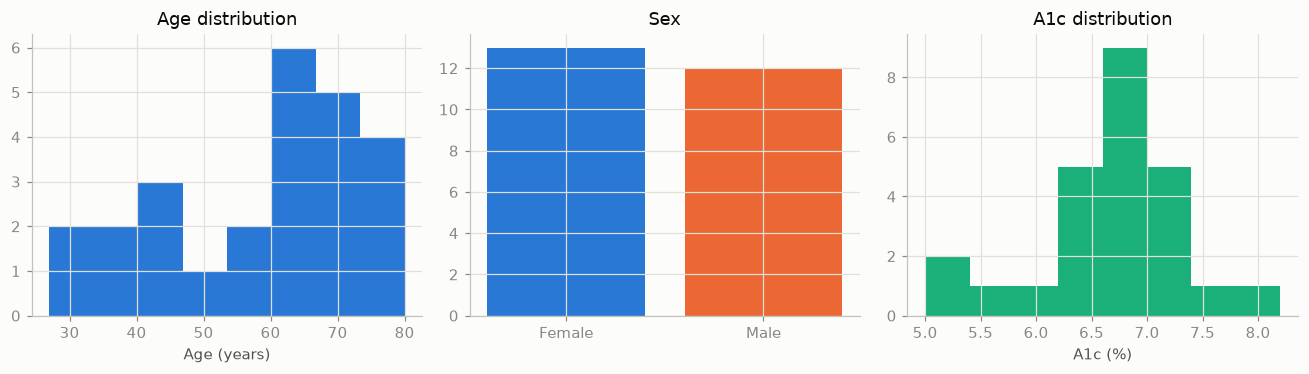

In [5]:
demo = ref.DEMOGRAPHICS_TABLE1
display(demo.describe(include="all"))

fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))

axes[0].hist(demo["age"], bins=8, color=plotting.CATEGORICAL[0])
axes[0].set_title("Age distribution")
axes[0].set_xlabel("Age (years)")

sex_counts = demo["sex"].value_counts()
axes[1].bar(sex_counts.index, sex_counts.values, color=plotting.CATEGORICAL[:len(sex_counts)])
axes[1].set_title("Sex")

axes[2].hist(demo["a1c_pct"], bins=8, color=plotting.CATEGORICAL[2])
axes[2].set_title("A1c distribution")
axes[2].set_xlabel("A1c (%)")

fig.tight_layout()
plt.show()


## 4. Glycemic control overview

Standard ambulatory glucose profile metrics per subject: time-in-range (70-180 mg/dL),
glucose management indicator (GMI, an estimated A1c from mean CGM), and coefficient of
variation (CV; >36% flags high glycemic variability).


In [6]:
summary = metrics.summary_table(df)
display(summary)


CGM,hypo,in_range,hyper,gmi_pct,cv_pct,n_readings
subject_id,,,,,,
1,1.0,84.6,14.4,6.7,25.7,10881
2,0.3,74.6,25.1,7.0,28.3,11189
3,1.3,83.4,15.3,6.7,29.2,10685
4,0.1,63.1,36.8,7.4,31.1,12750
5,4.0,81.4,14.6,6.5,32.4,13052
6,0.1,85.2,14.7,6.7,22.8,12730
7,0.9,85.0,14.1,6.7,25.6,13385
8,0.5,68.1,31.3,7.1,31.3,8040
9,1.7,44.8,53.6,7.9,35.3,10674


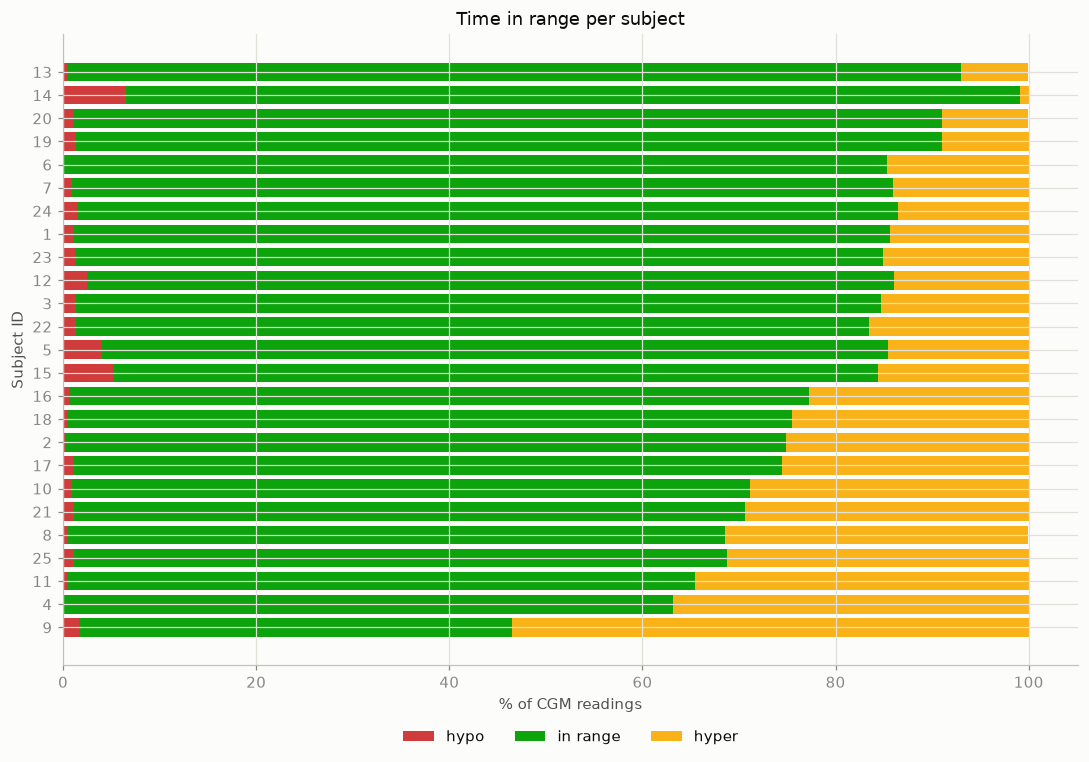

In [7]:
ordered = summary.sort_values("in_range", ascending=True)

fig, ax = plt.subplots(figsize=(10, 7))
bottom = np.zeros(len(ordered))
for band in ["hypo", "in_range", "hyper"]:
    ax.barh(ordered.index.astype(str), ordered[band], left=bottom,
            color=plotting.GLUCOSE_BAND_COLORS[band], label=band.replace("_", " "))
    bottom += ordered[band].to_numpy()

ax.set_xlabel("% of CGM readings")
ax.set_ylabel("Subject ID")
ax.set_title("Time in range per subject" + (" (synthetic placeholder data)" if USING_SYNTHETIC else ""))
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.08), ncol=3, frameon=False)
fig.tight_layout()
plt.show()


## 5. Daily glucose profile (single subject, single day)

Reproduces the shape of Fig. 2 in the paper: a day's CGM trace with hypo/hyperglycemia
bands shaded, and bolus/meal events marked where they occurred.


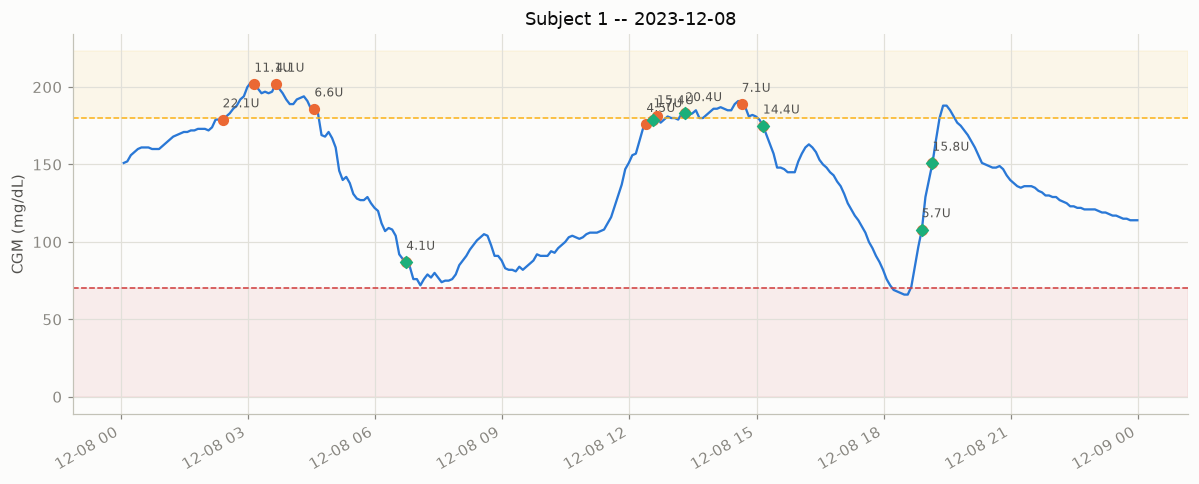

In [8]:
def plot_daily_profile(df, subject_id, date):
    day = df[(df["subject_id"] == subject_id) & (df[ref.EVENT_DATETIME].dt.date == pd.Timestamp(date).date())]
    if day.empty:
        raise ValueError(f"No data for subject {subject_id} on {date}")

    fig, ax = plt.subplots(figsize=(11, 4.5))
    ax.plot(day[ref.EVENT_DATETIME], day[ref.CGM], color=plotting.CATEGORICAL[0], linewidth=1.5)

    ax.axhspan(0, ref.HYPO_THRESHOLD, color=plotting.GLUCOSE_BAND_COLORS["hypo"], alpha=0.08)
    ax.axhspan(ref.HYPER_THRESHOLD, day[ref.CGM].max() + 20, color=plotting.GLUCOSE_BAND_COLORS["hyper"], alpha=0.08)
    ax.axhline(ref.HYPO_THRESHOLD, color=plotting.GLUCOSE_BAND_COLORS["hypo"], linestyle="--", linewidth=1)
    ax.axhline(ref.HYPER_THRESHOLD, color=plotting.GLUCOSE_BAND_COLORS["hyper"], linestyle="--", linewidth=1)

    bolus_events = day[day[ref.TOTAL_BOLUS_INSULIN_DELIVERED] > 0]
    for _, row in bolus_events.iterrows():
        ax.scatter(row[ref.EVENT_DATETIME], row[ref.CGM], color=plotting.CATEGORICAL[1], zorder=5, s=40)
        ax.annotate(f"{row[ref.TOTAL_BOLUS_INSULIN_DELIVERED]:.1f}U", (row[ref.EVENT_DATETIME], row[ref.CGM]),
                    textcoords="offset points", xytext=(0, 8), fontsize=8, color=plotting.INK_SECONDARY)

    carb_events = day[day[ref.CARB_SIZE] > 0]
    for _, row in carb_events.iterrows():
        ax.scatter(row[ref.EVENT_DATETIME], row[ref.CGM], color=plotting.CATEGORICAL[2], marker="D", zorder=5, s=30)

    ax.set_ylabel("CGM (mg/dL)")
    ax.set_title(f"Subject {subject_id} -- {pd.Timestamp(date).date()}"
                 + (" (synthetic placeholder data)" if USING_SYNTHETIC else ""))
    fig.autofmt_xdate()
    fig.tight_layout()
    plt.show()

example_subject = int(df["subject_id"].iloc[0])
example_date = df.loc[df["subject_id"] == example_subject, ref.EVENT_DATETIME].dt.date.iloc[3]
plot_daily_profile(df, example_subject, example_date)


## 6. Insulin & carbohydrate patterns

Per-subject-per-day totals for basal, bolus, and carbohydrate intake, and how bolus size
relates to bolus type.


In [9]:
daily = metrics.daily_carb_and_bolus(df)
display(daily.groupby("subject_id")[["total_carbs_g", "total_bolus_u", "total_basal_u"]].mean().round(1))


,total_carbs_g,total_bolus_u,total_basal_u
subject_id,,,
1,182.1,131.0,49.1
2,147.4,16.1,7.8
3,147.4,69.4,53.6
4,57.3,8.8,20.0
5,137.0,26.2,9.4
6,107.7,12.4,11.2
7,164.4,15.1,11.8
8,84.4,10.3,10.4
9,111.2,18.7,27.5


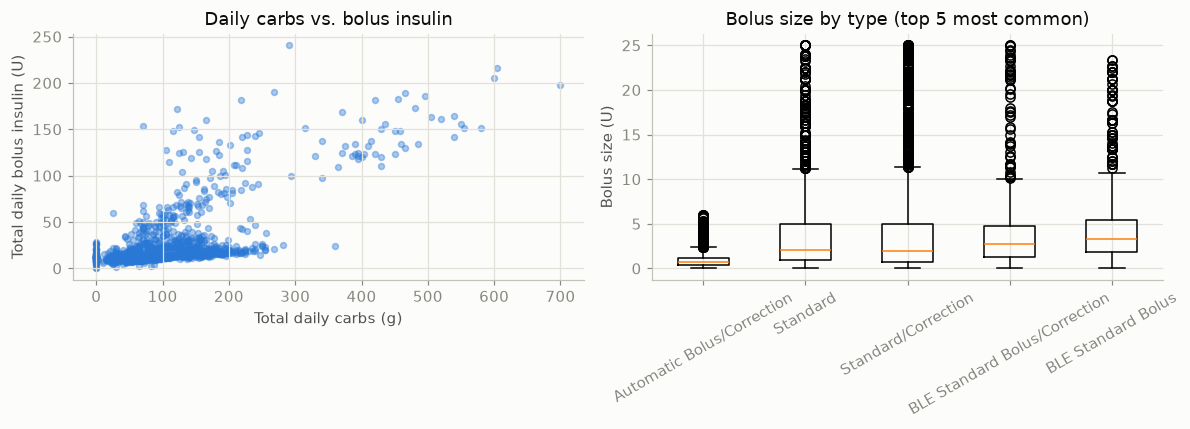

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].scatter(daily["total_carbs_g"], daily["total_bolus_u"], alpha=0.4, color=plotting.CATEGORICAL[0], s=15)
axes[0].set_xlabel("Total daily carbs (g)")
axes[0].set_ylabel("Total daily bolus insulin (U)")
axes[0].set_title("Daily carbs vs. bolus insulin")

# Real BolusType strings are much richer than the paper's standard/correction/automatic
# (e.g. "Extended 50.00%/8.31" encodes a per-event split+amount, so it's near-unique)
# -- group by the most common actual categories rather than a fixed list.
bolus_events = df[df[ref.TOTAL_BOLUS_INSULIN_DELIVERED] > 0]
top_types = bolus_events[ref.BOLUS_TYPE].value_counts().head(5).index.tolist()
by_type = [bolus_events.loc[bolus_events[ref.BOLUS_TYPE] == t, ref.TOTAL_BOLUS_INSULIN_DELIVERED] for t in top_types]
axes[1].boxplot(by_type, tick_labels=top_types)
axes[1].tick_params(axis="x", labelrotation=30)
axes[1].set_ylabel("Bolus size (U)")
axes[1].set_title("Bolus size by type (top 5 most common)")

fig.tight_layout()
plt.show()


## 7. Device mode & time-of-day patterns

Share of time in each device mode, and — echoing the paper's elderly-patient analysis
(Fig. 3) — hypo-/hyperglycemia burden by time-of-day block.


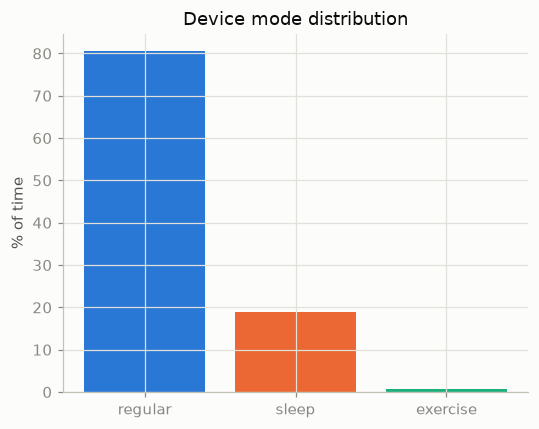

In [11]:
mode_dist = metrics.device_mode_distribution(df)
fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(mode_dist.index, mode_dist.values, color=plotting.CATEGORICAL[:len(mode_dist)])
ax.set_ylabel("% of time")
ax.set_title("Device mode distribution" + (" (synthetic placeholder data)" if USING_SYNTHETIC else ""))
fig.tight_layout()
plt.show()


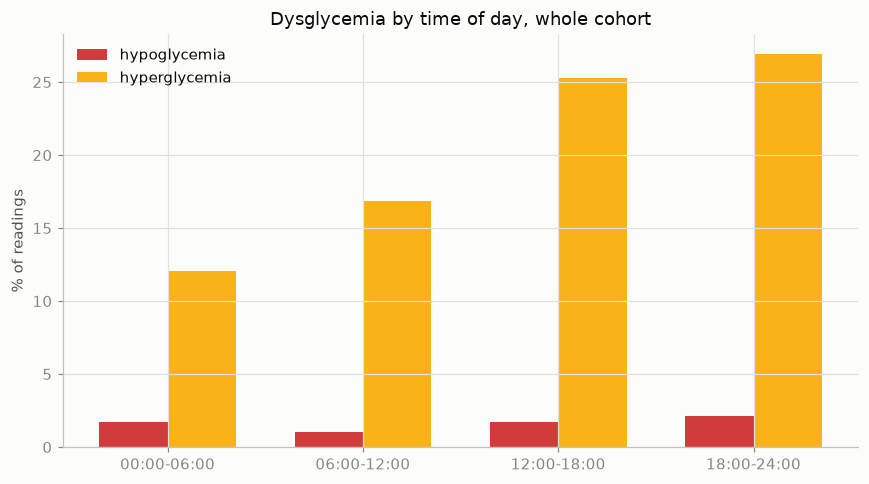

In [12]:
time_blocks = {
    "00:00-06:00": (0, 6),
    "06:00-12:00": (6, 12),
    "12:00-18:00": (12, 18),
    "18:00-24:00": (18, 24),
}

tagged = df.copy()
tagged["hour"] = tagged[ref.EVENT_DATETIME].dt.hour
tagged["block"] = pd.cut(
    tagged["hour"], bins=[0, 6, 12, 18, 24], labels=list(time_blocks.keys()), right=False, include_lowest=True
)
tagged["glycemic_state"] = pd.cut(
    tagged[ref.CGM], bins=[-np.inf, ref.HYPO_THRESHOLD, ref.HYPER_THRESHOLD, np.inf],
    labels=["hypo", "in_range", "hyper"],
)

block_pct = pd.crosstab(tagged["block"], tagged["glycemic_state"], normalize="index") * 100

fig, ax = plt.subplots(figsize=(8, 4.5))
x = np.arange(len(block_pct.index))
width = 0.35
ax.bar(x - width / 2, block_pct["hypo"], width, color=plotting.GLUCOSE_BAND_COLORS["hypo"], label="hypoglycemia")
ax.bar(x + width / 2, block_pct["hyper"], width, color=plotting.GLUCOSE_BAND_COLORS["hyper"], label="hyperglycemia")
ax.set_xticks(x)
ax.set_xticklabels(block_pct.index)
ax.set_ylabel("% of readings")
ax.set_title("Dysglycemia by time of day, whole cohort" + (" (synthetic placeholder data)" if USING_SYNTHETIC else ""))
ax.legend(frameon=False)
fig.tight_layout()
plt.show()


## 8. Write-up (fill in once real data has loaded)

Placeholder structure for the short write-up — replace the bullet points with actual
observations once the sections above are re-run against the real archive:

- **Cohort overview:** N subjects, age/sex/A1c spread, total monitoring time.
- **Glycemic control:** how time-in-range and GMI compare across subjects; any subjects
  far outside the 70%+ TIR consensus target.
- **Daily patterns:** what a typical day looks like (Section 5); how much bolus/carb
  variability there is day-to-day (Section 6).
- **Time-of-day risk:** whether hypo-/hyperglycemia cluster at particular times, as the
  source paper found for elderly patients overnight and in the evening (Section 7).
- **Anything dataset-specific to flag:** sensor gaps, subjects with unusually short
  follow-up, or fields that didn't match the expected schema during loading.
